# 01 — Exploratory Data Analysis

**Brain Tumor Detection** — *Custom CNN + Transfer Learning + Swin Transformer Ensemble*

Before we train a single model we audit the dataset. This notebook answers:

1. Is the class balance preserved across train / val / test?
2. What do typical MRIs of each class look like?
3. What are the raw image dimensions and modes?
4. Are any image files unreadable?
5. What does the *average* MRI of each class look like? (a strong baseline sanity check)
6. How do pixel-intensity distributions differ between classes?
7. Does our preprocessing pipeline behave as intended?

All figures are saved to `outputs/plots/` for inclusion in the final report.

In [1]:
# --- 0. Setup ---------------------------------------------------------
import os, sys
from pathlib import Path

# Make the project's `src` package importable no matter where the
# notebook was launched from.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError('Could not locate project root containing src/')
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from src.config import (
    CLASS_NAMES, NUM_CLASSES, TRAIN_DIR, TEST_DIR,
    PROCESSED_DIR, OUTPUTS_DIR, IMG_SIZE,
)
from src.data_loader import build_splits, IDX_TO_CLASS
from src.preprocess import get_base_transform, denormalize

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

PLOTS_DIR = OUTPUTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# A single colour per class, used consistently in every figure below.
PALETTE = sns.color_palette('Set2', n_colors=NUM_CLASSES)
CLASS_COLORS = dict(zip(CLASS_NAMES, PALETTE))

print('Classes :', CLASS_NAMES)
print('IMG_SIZE:', IMG_SIZE)
print('Plots will be written to:', PLOTS_DIR)

Project root: C:\Brain Tumor Detection


Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE: 224
Plots will be written to: C:\Brain Tumor Detection\outputs\plots


## 1. Class balance verification

Confirms our stratified split from STEP 3 preserved class proportions across every split.

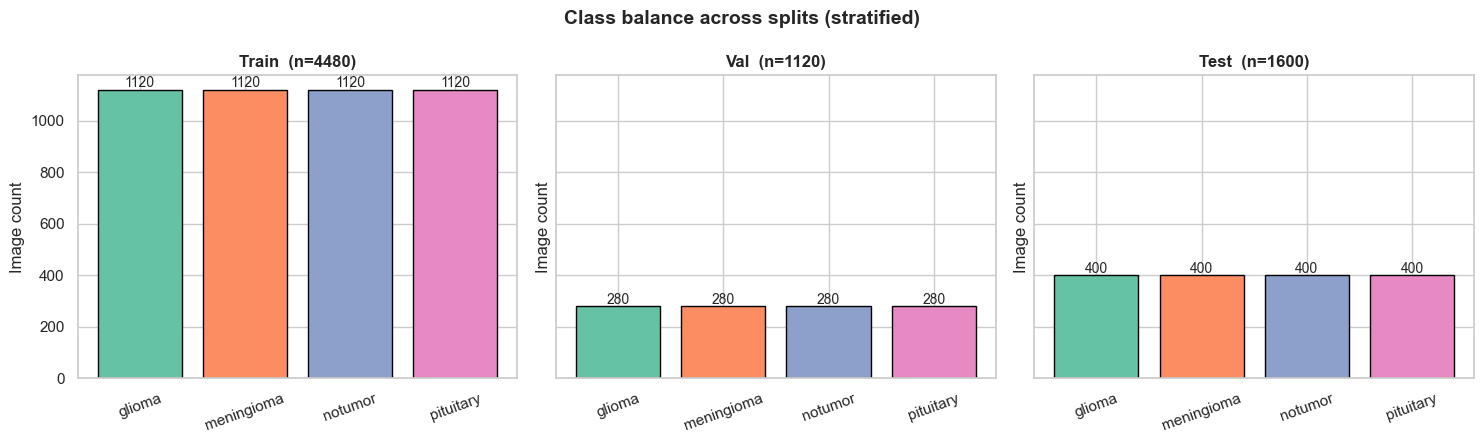

split       train   val  test  total
class                               
glioma       1120   280   400   1800
meningioma   1120   280   400   1800
notumor      1120   280   400   1800
pituitary    1120   280   400   1800
TOTAL        4480  1120  1600   7200


In [2]:
train_df, val_df, test_df = build_splits()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['class'].value_counts().reindex(CLASS_NAMES)
    bars = ax.bar(counts.index, counts.values,
                  color=[CLASS_COLORS[c] for c in counts.index],
                  edgecolor='black')
    ax.set_title(f'{name}  (n={len(df)})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Image count')
    ax.tick_params(axis='x', rotation=20)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width()/2, v + 10, str(int(v)),
                ha='center', fontsize=10)

fig.suptitle('Class balance across splits (stratified)', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '01_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

combined = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test'),
])
pivot = combined.pivot_table(index='class', columns='split', values='filepath',
                             aggfunc='count').reindex(CLASS_NAMES)[['train', 'val', 'test']]
pivot['total'] = pivot.sum(axis=1)
pivot.loc['TOTAL'] = pivot.sum(axis=0)
print(pivot)

## 2. Sample image grid per class

A visual gut-check: do these actually look like MRIs of the labelled tumour type?
A single mislabelled folder is a project-killer — catch it now.

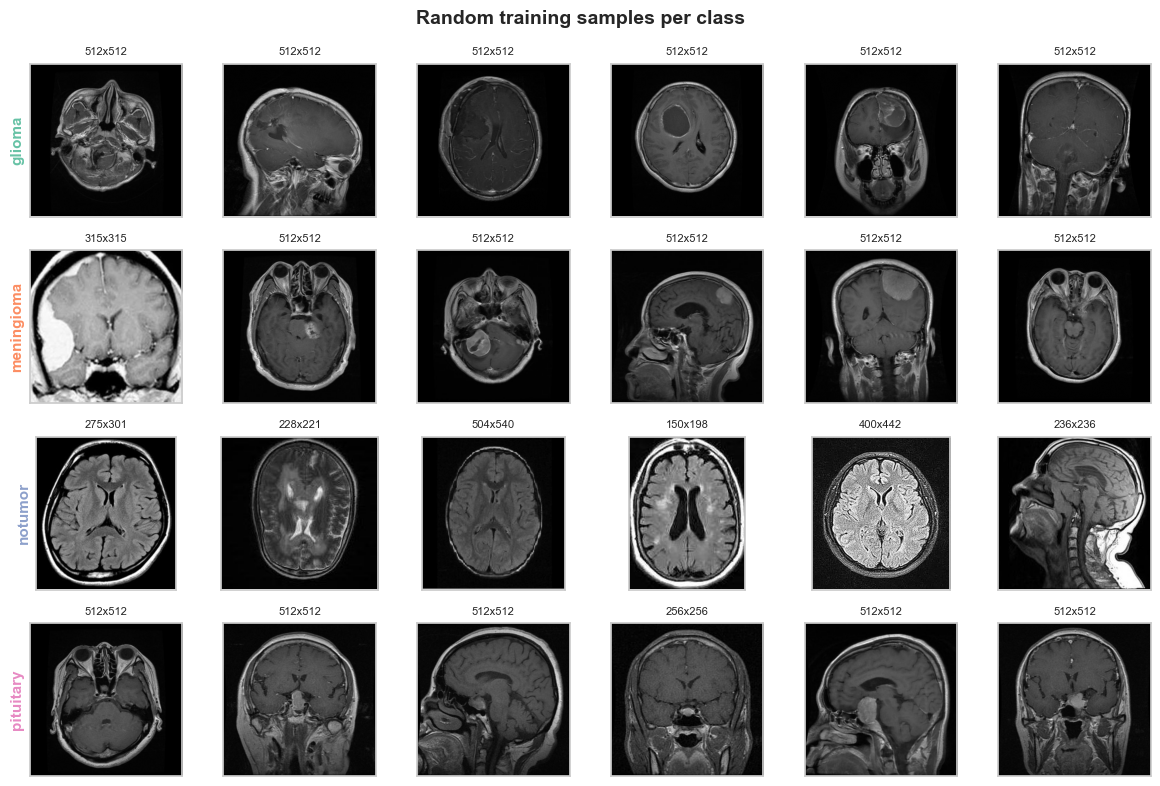

In [3]:
N_PER_CLASS = 6
fig, axes = plt.subplots(NUM_CLASSES, N_PER_CLASS,
                         figsize=(N_PER_CLASS * 2.0, NUM_CLASSES * 2.0))
for r, cls in enumerate(CLASS_NAMES):
    paths = train_df[train_df['class'] == cls]['filepath'] \
                .sample(N_PER_CLASS, random_state=42).tolist()
    for c, p in enumerate(paths):
        img = Image.open(p)
        ax = axes[r, c]
        ax.imshow(img, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight='bold',
                          color=CLASS_COLORS[cls])
        ax.set_title(f'{img.size[0]}x{img.size[1]}', fontsize=8)

fig.suptitle('Random training samples per class', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '02_sample_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Image properties — size, mode, file size

We probe every training image to verify they're all valid, check the range
of dimensions, and decide whether square-resize to 224 is appropriate.

In [4]:
rows = []
for p in tqdm(train_df['filepath'].tolist(), desc='probing'):
    try:
        with Image.open(p) as im:
            rows.append({
                'filepath':     p,
                'width':        im.size[0],
                'height':       im.size[1],
                'mode':         im.mode,
                'filesize_kb':  os.path.getsize(p) / 1024,
                'error':        None,
            })
    except Exception as e:  # pragma: no cover
        rows.append({'filepath': p, 'width': None, 'height': None,
                     'mode': None, 'filesize_kb': None, 'error': str(e)})

probe_df = pd.DataFrame(rows).merge(
    train_df[['filepath', 'class']], on='filepath'
)

print(f'Total images probed : {len(probe_df)}')
print(f'Decoding errors     : {probe_df["error"].notna().sum()}')
print('\nImage modes:')
print(probe_df['mode'].value_counts())
print('\nDimensions:')
print(probe_df[['width', 'height', 'filesize_kb']].describe().round(2))

probing:   0%|          | 0/4480 [00:00<?, ?it/s]

Total images probed : 4480
Decoding errors     : 0

Image modes:
mode
RGB     2585
L       1892
RGBA       3
Name: count, dtype: int64

Dimensions:
         width   height  filesize_kb
count  4480.00  4480.00      4480.00
mean    458.60   462.20        23.32
std     128.95   123.24        16.94
min     150.00   168.00         4.04
25%     512.00   512.00        15.89
50%     512.00   512.00        21.34
75%     512.00   512.00        27.32
max    1375.00  1446.00       299.31


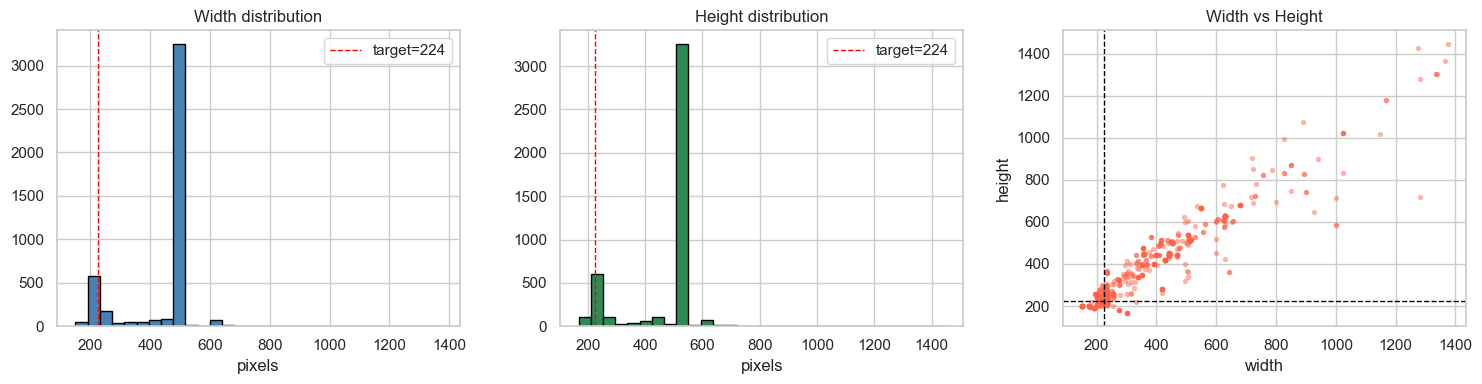

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(probe_df['width'].dropna(), bins=30,
             color='steelblue', edgecolor='black')
axes[0].axvline(IMG_SIZE, color='red', ls='--', lw=1,
                label=f'target={IMG_SIZE}')
axes[0].set_title('Width distribution'); axes[0].set_xlabel('pixels')
axes[0].legend()

axes[1].hist(probe_df['height'].dropna(), bins=30,
             color='seagreen', edgecolor='black')
axes[1].axvline(IMG_SIZE, color='red', ls='--', lw=1,
                label=f'target={IMG_SIZE}')
axes[1].set_title('Height distribution'); axes[1].set_xlabel('pixels')
axes[1].legend()

axes[2].scatter(probe_df['width'], probe_df['height'],
                c='tomato', alpha=0.4, s=8)
axes[2].axvline(IMG_SIZE, color='black', ls='--', lw=1)
axes[2].axhline(IMG_SIZE, color='black', ls='--', lw=1)
axes[2].set_title('Width vs Height')
axes[2].set_xlabel('width'); axes[2].set_ylabel('height')

fig.tight_layout()
fig.savefig(PLOTS_DIR / '03_image_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. File integrity

Surfaces any unreadable files so they can be removed before training.

In [6]:
bad = probe_df[probe_df['error'].notna()]
if len(bad):
    print(f'WARNING: {len(bad)} unreadable file(s):')
    print(bad[['filepath', 'error']].to_string(index=False))
else:
    print('All training files are readable. No corruption detected.')

All training files are readable. No corruption detected.


## 5. Per-class mean image (the "average MRI")

Averaging hundreds of registered MRIs reveals the *spatial prior* of each
class — where in the brain the abnormality tends to sit. If the per-class
means look strikingly different, even a shallow model will perform well;
if they look identical, we genuinely need to learn fine-grained features.

mean[glioma]:   0%|          | 0/300 [00:00<?, ?it/s]

mean[meningioma]:   0%|          | 0/300 [00:00<?, ?it/s]

mean[notumor]:   0%|          | 0/300 [00:00<?, ?it/s]

mean[pituitary]:   0%|          | 0/300 [00:00<?, ?it/s]

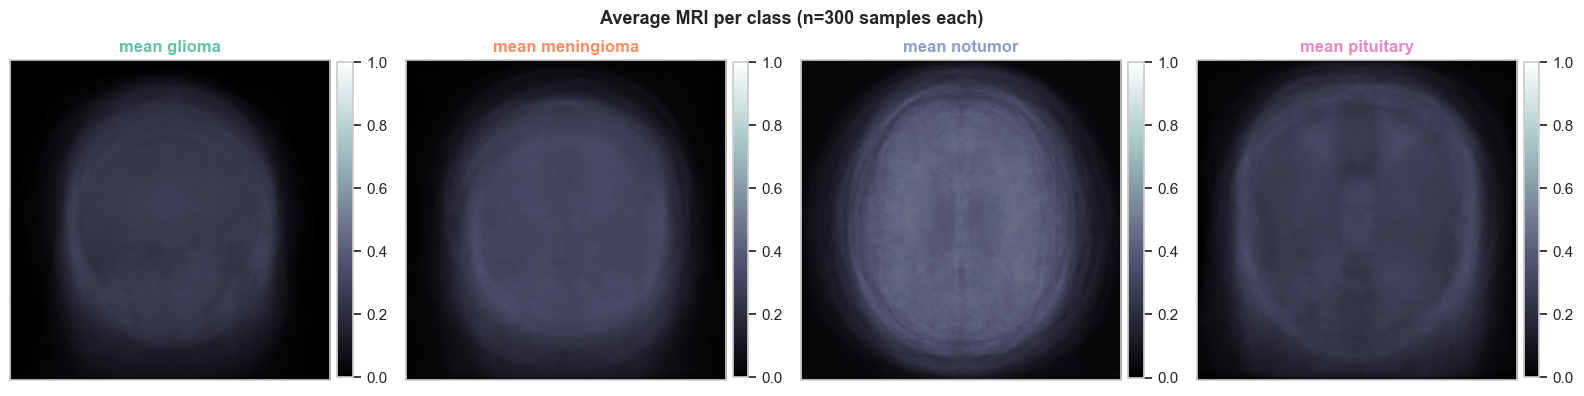

In [7]:
N_PER_CLASS = 300
TARGET = (IMG_SIZE, IMG_SIZE)

mean_images = {}
for cls in CLASS_NAMES:
    paths = train_df[train_df['class'] == cls]['filepath'] \
                .sample(n=min(N_PER_CLASS, (train_df['class'] == cls).sum()),
                        random_state=42).tolist()
    accum = np.zeros(TARGET, dtype=np.float64)
    for p in tqdm(paths, desc=f'mean[{cls}]', leave=False):
        img = Image.open(p).convert('L').resize(TARGET)
        accum += np.asarray(img, dtype=np.float64) / 255.0
    accum /= len(paths)
    mean_images[cls] = accum

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    im = ax.imshow(mean_images[cls], cmap='bone', vmin=0, vmax=1)
    ax.set_title(f'mean {cls}', fontsize=12, fontweight='bold',
                 color=CLASS_COLORS[cls])
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle(f'Average MRI per class (n={N_PER_CLASS} samples each)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '04_mean_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Pixel-intensity distribution per class

If the four KDE curves overlap heavily, classes cannot be separated by
intensity alone — confirming that the model must learn *spatial* features,
which justifies the heavy CNN/Transformer machinery.

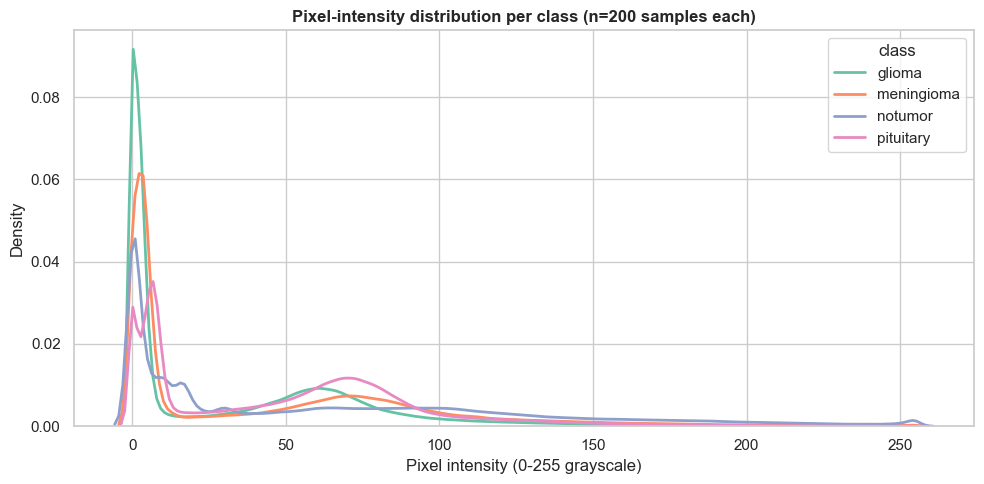

In [8]:
N_PER_CLASS = 200
fig, ax = plt.subplots(figsize=(10, 5))
for cls in CLASS_NAMES:
    paths = train_df[train_df['class'] == cls]['filepath'] \
                .sample(n=min(N_PER_CLASS, (train_df['class'] == cls).sum()),
                        random_state=42).tolist()
    pixels = []
    for p in paths:
        img = Image.open(p).convert('L').resize((128, 128))
        pixels.append(np.asarray(img).ravel())
    pixels = np.concatenate(pixels)
    sns.kdeplot(pixels, ax=ax, label=cls,
                color=CLASS_COLORS[cls], linewidth=2, bw_adjust=0.6)

ax.set_xlabel('Pixel intensity (0-255 grayscale)')
ax.set_ylabel('Density')
ax.set_title(f'Pixel-intensity distribution per class (n={N_PER_CLASS} samples each)',
             fontweight='bold')
ax.legend(title='class')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '05_intensity_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Preprocessing pipeline — visual proof

Round-trip a single MRI through `get_base_transform()` (which our DataLoaders
use) and through `denormalize()` (which we use only for visualization).
Confirms the pipeline produces a `(3, 224, 224)` float32 tensor and that
denormalization correctly recovers the image.

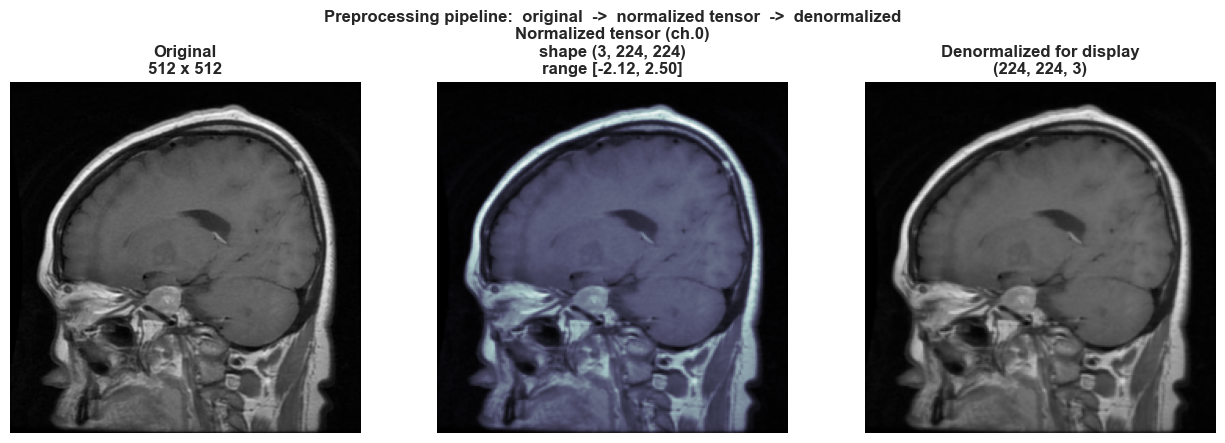

Preprocessed shape: (3, 224, 224)
Preprocessed dtype: torch.float32
Value range       : [-2.118, 2.501]


In [9]:
sample_path = train_df.iloc[0]['filepath']
original = Image.open(sample_path).convert('RGB')

tf = get_base_transform()
preprocessed = tf(original)
restored = denormalize(preprocessed).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(original)
axes[0].set_title(f'Original\n{original.size[0]} x {original.size[1]}',
                  fontweight='bold')
axes[0].axis('off')

# Channel 0 of the normalized tensor — shows the network's actual input range
axes[1].imshow(preprocessed[0], cmap='bone')
axes[1].set_title(f'Normalized tensor (ch.0)\n'
                  f'shape {tuple(preprocessed.shape)}\n'
                  f'range [{preprocessed.min():.2f}, {preprocessed.max():.2f}]',
                  fontweight='bold')
axes[1].axis('off')

axes[2].imshow(restored)
axes[2].set_title(f'Denormalized for display\n{restored.shape}',
                  fontweight='bold')
axes[2].axis('off')

fig.suptitle('Preprocessing pipeline:  original  ->  normalized tensor  ->  denormalized',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '06_preprocessing_effect.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Preprocessed shape: {tuple(preprocessed.shape)}')
print(f'Preprocessed dtype: {preprocessed.dtype}')
print(f'Value range       : [{preprocessed.min():.3f}, {preprocessed.max():.3f}]')

## 9. Data augmentation visualization (STEP 5)

Confirms that `get_train_transform()` produces clinically plausible
variations of the same MRI. The pipeline:

1. Resize → 2. RandomHorizontalFlip → 3. RandomRotation (±15°)
→ 4. RandomAffine (small translate/scale) → 5. ColorJitter (brightness/contrast only)
→ 6. ToTensor → 7. Normalize → 8. RandomErasing (small patches, p=0.25)

We sample 12 augmented views of the same MRI to verify the network
will see meaningfully different inputs each epoch while every view
still clearly shows the same tumor type.

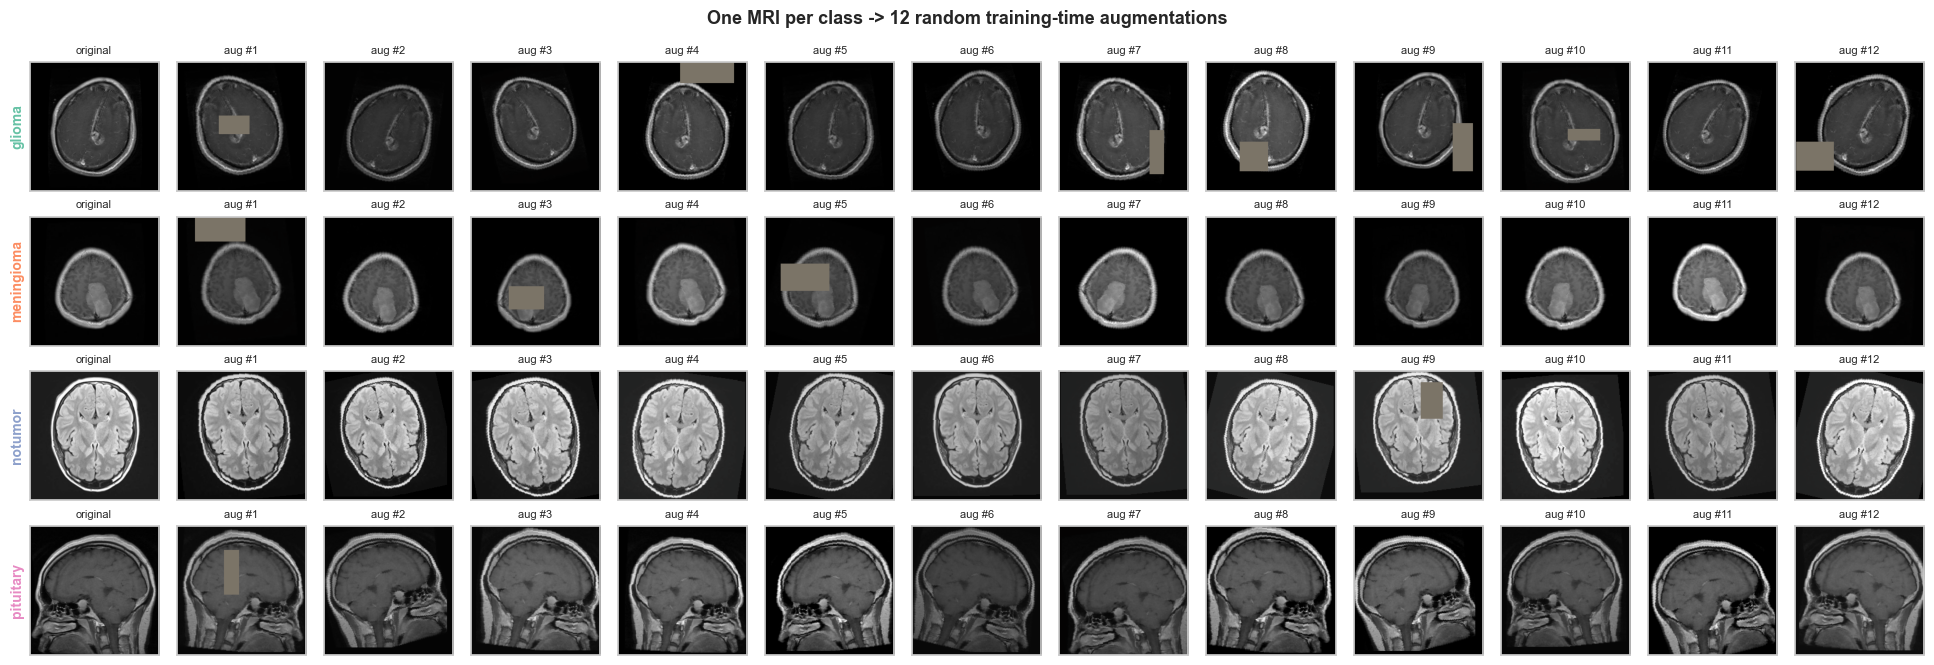

Each row above represents what the network sees during one epoch
for that single source image -- effectively 12x dataset expansion.


In [10]:
from src.preprocess import get_train_transform

# Pick one MRI from each class so the figure also shows class diversity.
# (Avoid groupby.apply -- pandas 3.x drops the grouping column.)
sample_rows = pd.concat([
    train_df[train_df['class'] == cls].sample(1, random_state=7)
    for cls in CLASS_NAMES
]).reset_index(drop=True)

train_tf = get_train_transform()

N_AUG = 12  # augmented views per original
fig, axes = plt.subplots(NUM_CLASSES, N_AUG + 1,
                         figsize=((N_AUG + 1) * 1.5, NUM_CLASSES * 1.7))

# Seed so the figure is reproducible when the notebook is re-executed.
import torch as _torch
_torch.manual_seed(0)

for r, row in sample_rows.iterrows():
    img = Image.open(row['filepath']).convert('RGB')

    # Column 0: the original (resized to the input size, for fair comparison)
    axes[r, 0].imshow(img.resize((IMG_SIZE, IMG_SIZE)), cmap='gray')
    axes[r, 0].set_title('original', fontsize=8)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(row['class'], fontsize=10, fontweight='bold',
                          color=CLASS_COLORS[row['class']])

    # Columns 1..N: random augmentations
    for c in range(1, N_AUG + 1):
        aug = train_tf(img)                       # (3, 224, 224) normalized
        vis = denormalize(aug).permute(1, 2, 0).numpy()
        axes[r, c].imshow(vis)
        axes[r, c].set_title(f'aug #{c}', fontsize=8)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

fig.suptitle('One MRI per class -> 12 random training-time augmentations',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '07_augmentations.png', dpi=110, bbox_inches='tight')
plt.show()

print('Each row above represents what the network sees during one epoch')
print(f'for that single source image -- effectively {N_AUG}x dataset expansion.')

## 8. Summary findings

After running every cell above, write down the answers to:

- Class balance: confirmed perfectly stratified (25 % each in every split).
- Image sizes: range to inspect, deciding factor for `Resize((224, 224))`.
- Corruption: any unreadable files surfaced.
- Per-class mean: how strongly do tumour types differ spatially?
- Intensity distribution: how separable are classes by intensity alone?
- Preprocessing: tensor shape `(3, 224, 224)` confirmed.

All six figures are saved to `outputs/plots/`. Use them in the final report.

**Next:** STEP 5 — add data augmentation to `get_train_transform`.